# 얼굴 부위 분할 (랜드마크 다각형 → 6부위)

- 랜드마크를 이어 만든 **다각형**으로 부위를 추출한다.
- 다각형 중 **피부 분할 모델의 '얼굴 피부'인 픽셀만** 남기고 나머지는 검정(0)으로 채운다 (배경·머리카락 제거).
- **눈가는 눈 가림 막대의 좌/우 끝을 한 변으로 쓴다.** 나머지 변은 랜드마크(눈썹 꼬리·관자놀이·광대)다.
- 윤곽 랜드마크 번호와 이마 확장 비율은 `face_regions.py`의 `POLYGONS`, `FOREHEAD_EXTEND`에 있다.
- **좌/우는 데이터셋 라벨과 같은 '사진 기준'**: 정면 사진에서 화면 왼쪽이 좌(`l_`)
- 크롭은 원본 해상도에서 자른다.
- 측면 사진에서 가려지는 부위(L 사진 → 좌 눈가·볼, R 사진 → 우 눈가·볼)는 `is_visible` 규칙으로 제외한다. 저장 단계(`extract_regions.ipynb`)와 같은 규칙이다.

In [167]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

import importlib

import face_regions

importlib.reload(face_regions)  # face_regions.py 수정사항을 커널 재시작 없이 반영
from face_regions import (CANVAS, DATA_DIR, REGION_NAMES, TARGET_FACE_HEIGHT, create_landmarker, create_segmenter,
                          crop_polygon, detect_landmarks, eye_bar_box, face_height, face_skin_mask, is_visible,
                          normalize_crop, region_polygons)

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

KOREAN = {"forehead": "이마", "glabella": "미간", "l_eye": "눈가 좌", "r_eye": "눈가 우", "l_cheek": "볼 좌", "r_cheek": "볼 우"}
COLORS = {"forehead": "lime", "glabella": "yellow", "l_eye": "cyan", "r_eye": "cyan", "l_cheek": "magenta", "r_cheek": "magenta"}
# 다이어그램과 같은 배치: 1행 이마/볼 좌/눈가 좌, 2행 미간/볼 우/눈가 우
GRID = [["forehead", "l_cheek", "l_eye"], ["glabella", "r_cheek", "r_eye"]]

## 사진 선택

`DEVICE`, `SUBJECT`를 바꾸면 다른 사람을 볼 수 있다.

In [168]:
DEVICE = "3. 스마트폰"
SUBJECT = input('사진번호')

images = sorted((DATA_DIR / "Training/01.원천데이터" / DEVICE / SUBJECT).glob("*.jpg"))
[p.name for p in images]

['0509_03_F.jpg', '0509_03_L.jpg', '0509_03_R.jpg']

In [169]:
results = {}
with create_landmarker() as landmarker, create_segmenter() as segmenter:
    for path in images:
        bgr = cv2.imread(str(path))
        points = detect_landmarks(landmarker, bgr)
        if points is None:
            print(f"[얼굴 없음] {path.name}")
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        view = path.stem.split("_")[2]  # 0002_03_F → F
        bar = eye_bar_box(rgb, points)  # 눈 가림 막대 위치 (눈가 영역의 한 변으로 쓴다)
        polygons = region_polygons(points, bar)
        skin = face_skin_mask(segmenter, rgb, points)
        results[path.stem] = dict(
            rgb=rgb,
            polygons=polygons,
            face_h=face_height(points),
            bar=bar,
            visible={name: is_visible(view, name) for name in polygons},
            crops={name: crop_polygon(rgb, poly, skin) if is_visible(view, name) else None
                   for name, poly in polygons.items()},
        )
        print(f"[OK] {path.name}")

W0000 00:00:1790065051.550091 1233486 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1790065051.559065 1233486 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
W0000 00:00:1790065051.560743 1233489 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790065051.569029 1233489 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1790065051.579119 1233498 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
W0000 00:00:1790065051.607188 1233500 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[OK] 0509_03_F.jpg
[OK] 0509_03_L.jpg
[OK] 0509_03_R.jpg


## 사진 위에 부위 표시

외곽선 = 랜드마크 다각형, 색칠 = 실제로 남는 픽셀 (다각형 ∩ 얼굴 피부). 가려지는 부위는 그리지 않는다.

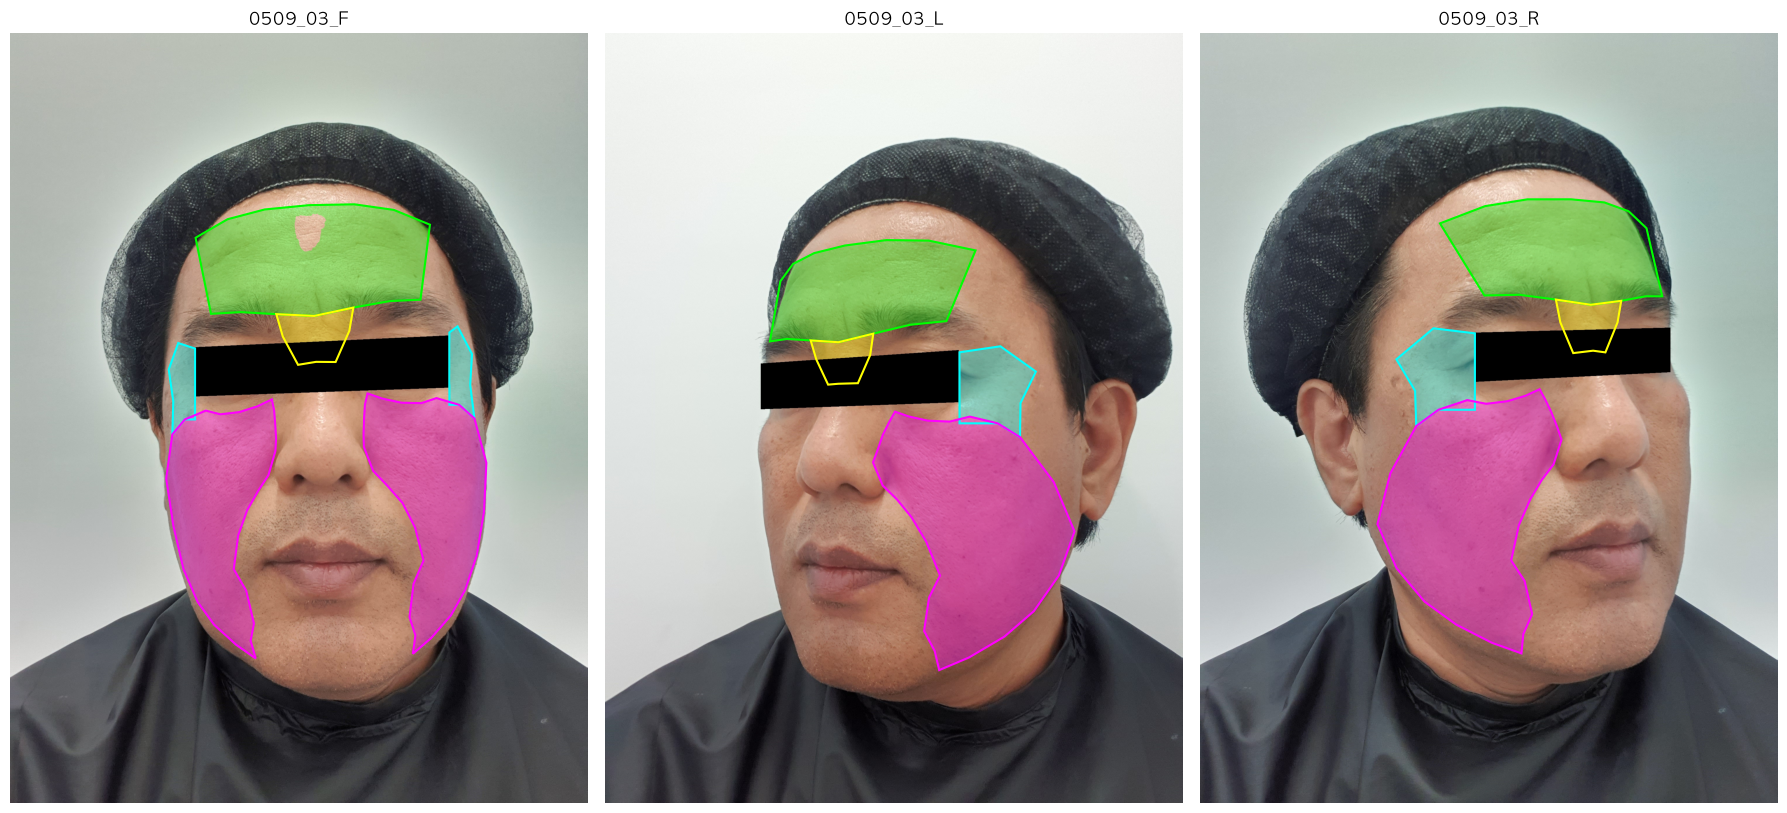

In [170]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 8), squeeze=False)
for ax, (stem, r) in zip(axes[0], results.items()):
    ax.imshow(r["rgb"])
    overlay = np.zeros((*r["rgb"].shape[:2], 4))
    for name in REGION_NAMES:
        if not r["visible"][name]:
            continue
        poly = r["polygons"][name]
        ax.add_patch(Polygon(poly, closed=True, fill=False, ec=COLORS[name], lw=1.5))
        if r["crops"][name] is None:
            continue
        _, mask = r["crops"][name]
        x1, y1 = np.floor(poly.min(0)).astype(int).clip(0)
        region = overlay[y1:y1 + mask.shape[0], x1:x1 + mask.shape[1]]
        region[mask.astype(bool)] = (*plt.matplotlib.colors.to_rgb(COLORS[name]), 0.35)
    ax.imshow(overlay)
    ax.set_title(stem)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 얼굴 부위 분할 섹션 (원본 해상도, 남긴 픽셀 외에는 검정)

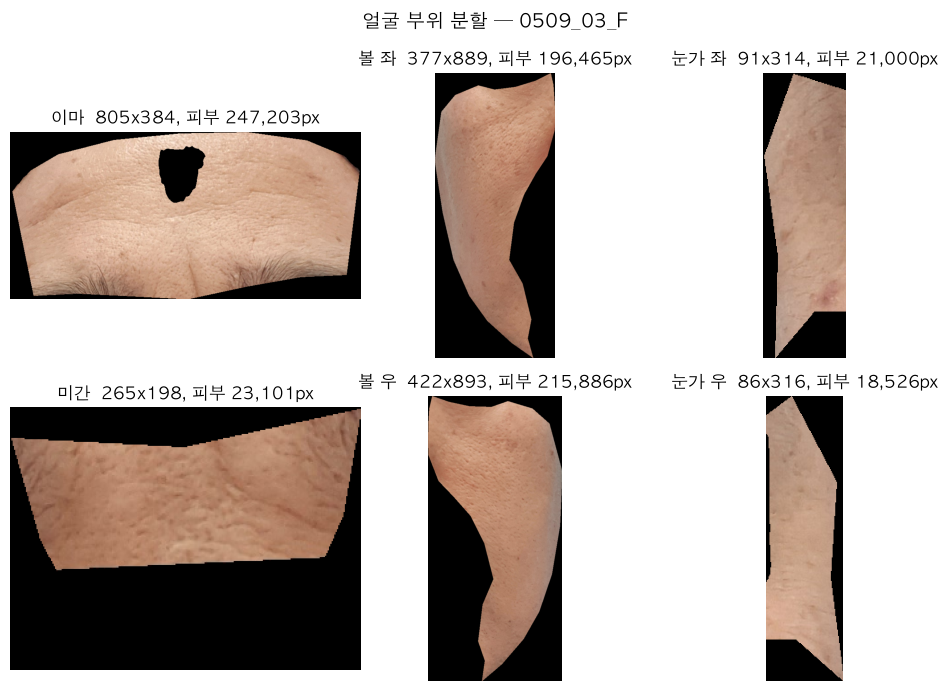

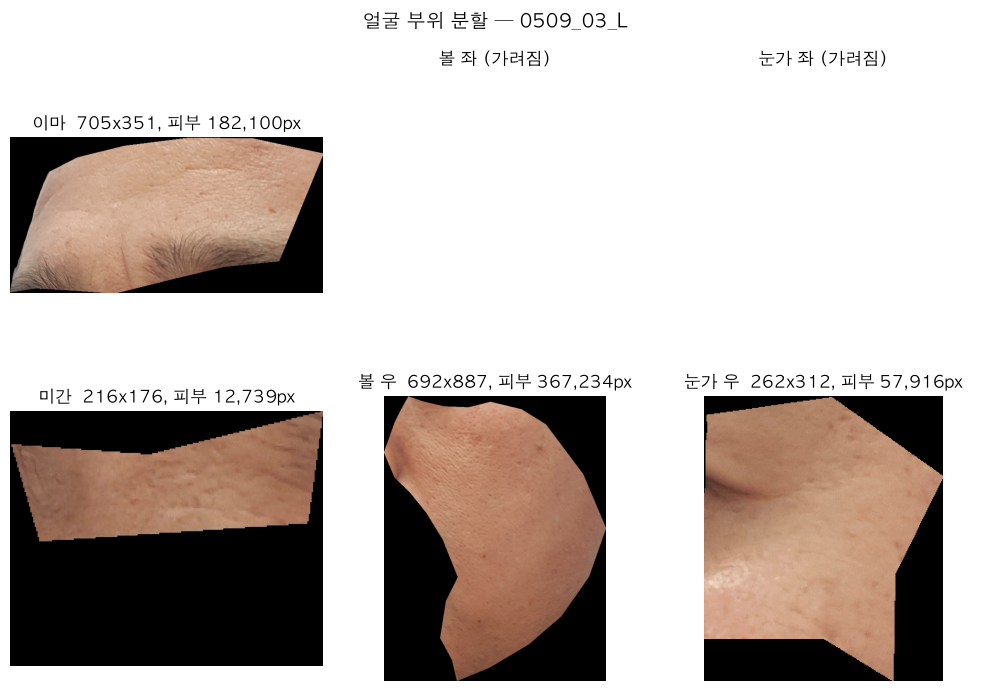

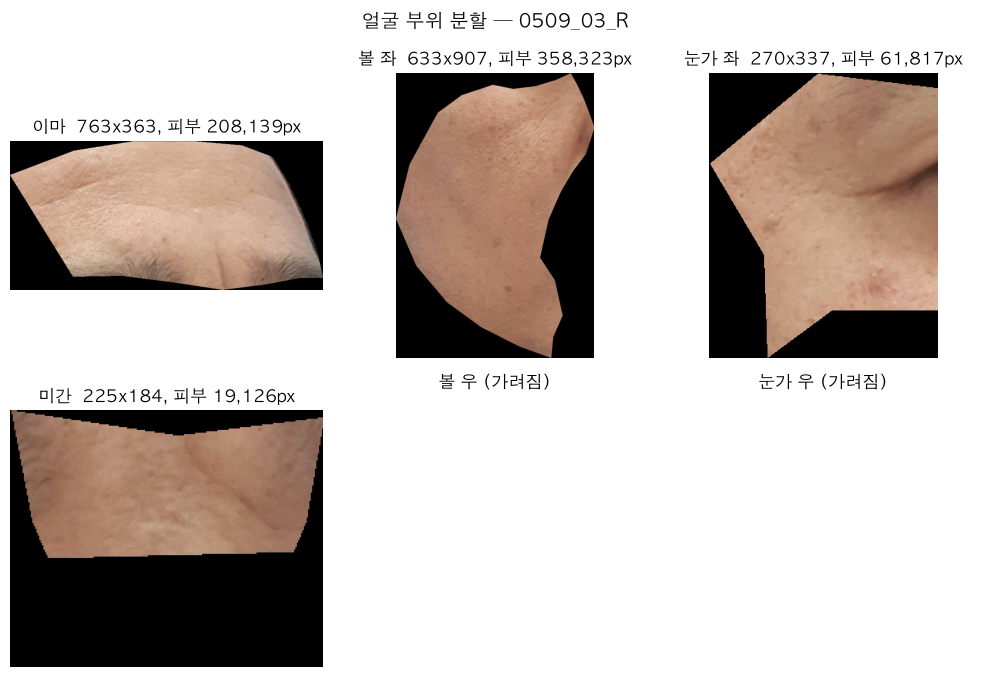

In [171]:
for stem, r in results.items():
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    fig.suptitle(f"얼굴 부위 분할 — {stem}", fontsize=14)
    for row, names in zip(axes, GRID):
        for ax, name in zip(row, names):
            ax.axis("off")
            if r["crops"][name] is None:
                ax.set_title(f"{KOREAN[name]} ({'가려짐' if not r['visible'][name] else '없음'})")
                continue
            crop, mask = r["crops"][name]
            ax.imshow(crop)
            ax.set_title(f"{KOREAN[name]}  {crop.shape[1]}x{crop.shape[0]}, 피부 {mask.sum():,}px")
    plt.tight_layout()
    plt.show()

## 정규화 후 (배율 통일 + 부위별 고정 크기)

얼굴 세로 길이를 모두 같게 맞춘 뒤 부위별 캔버스에 담은 결과. 칸 안의 상대 크기가 실제 크기 비율이다.


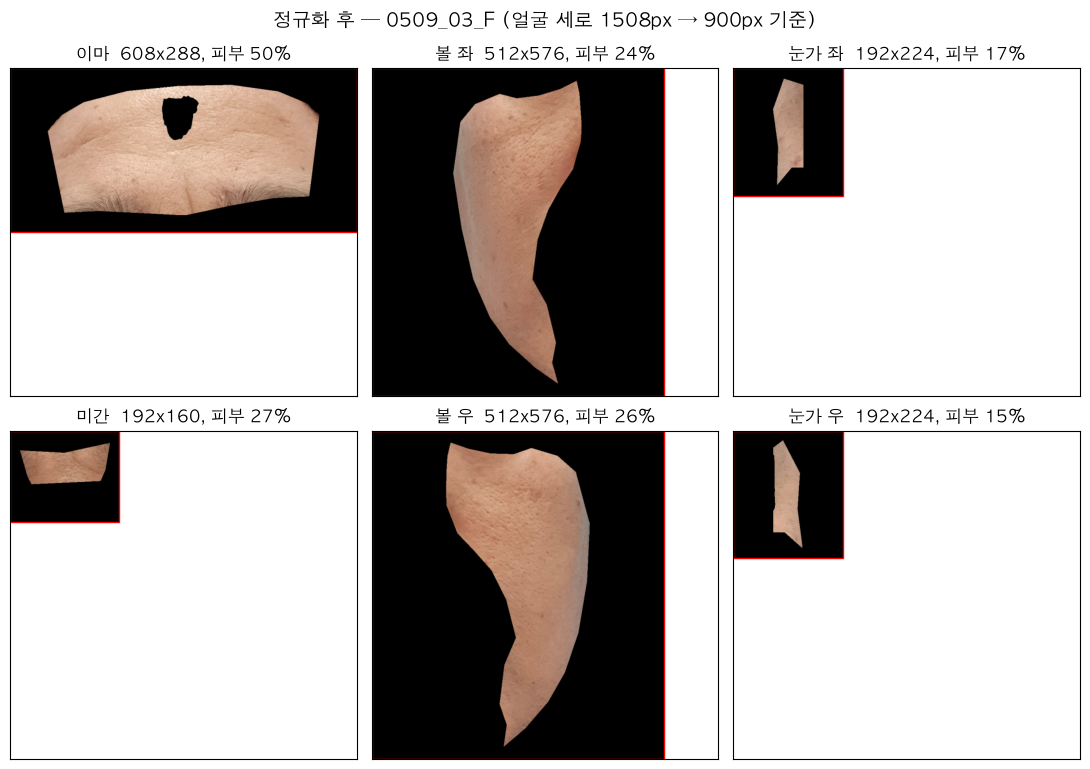

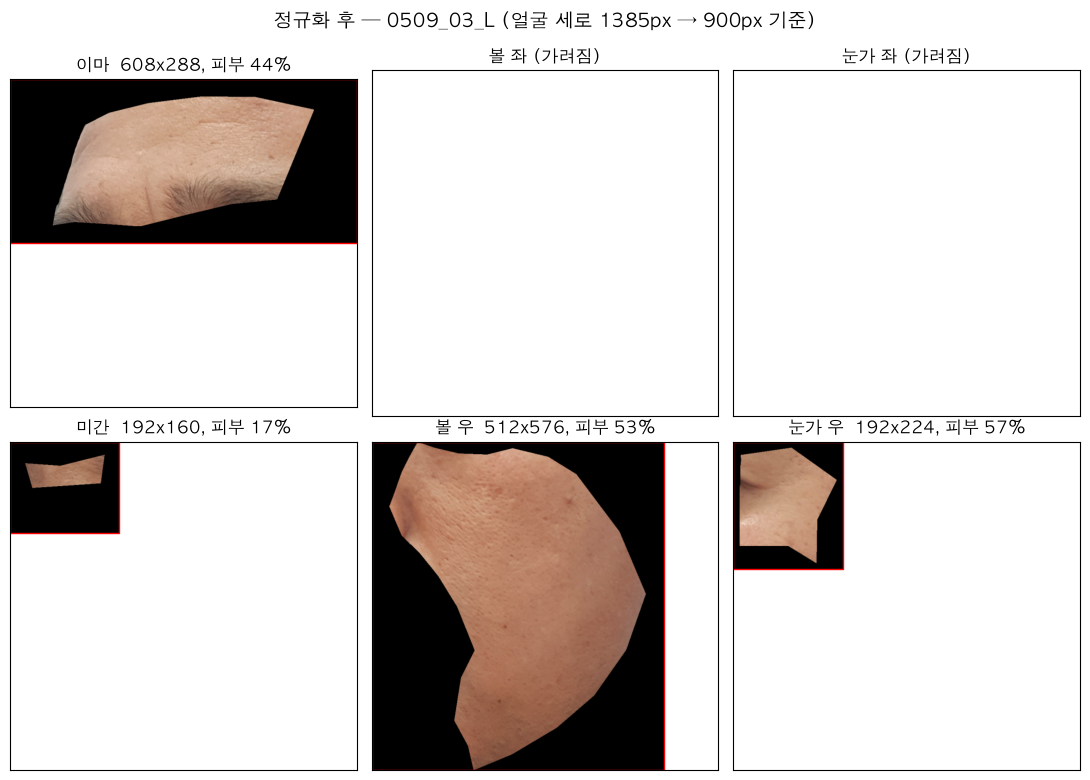

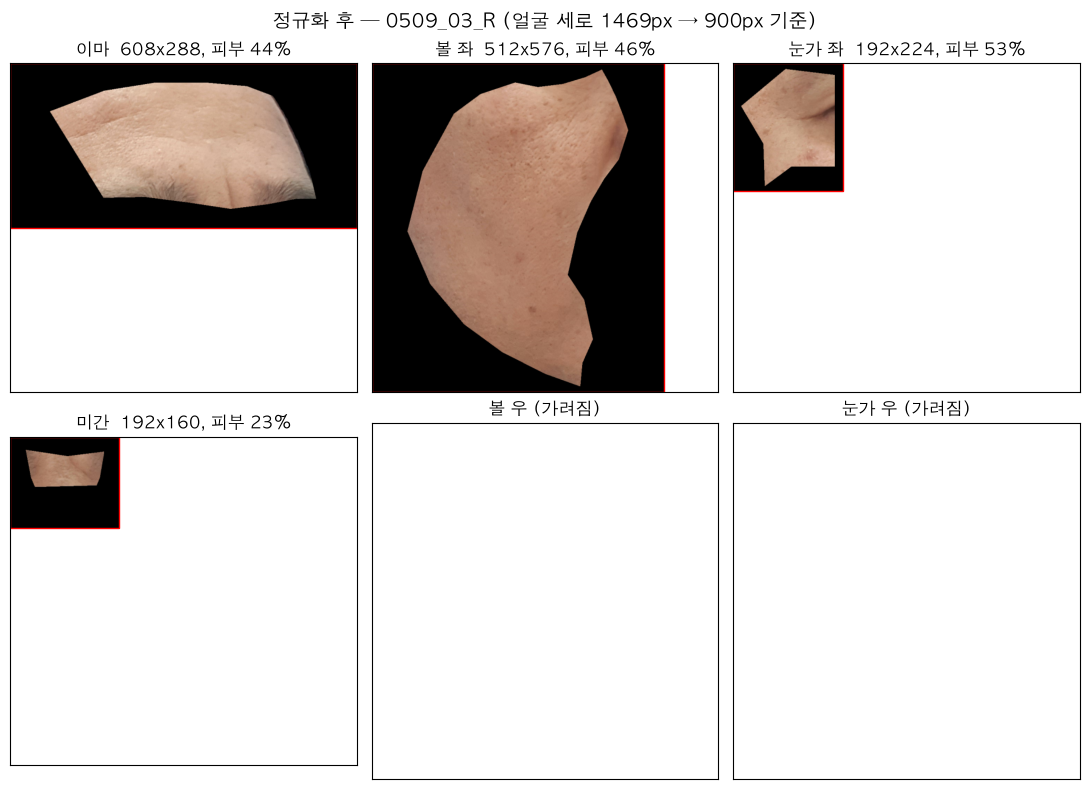

In [172]:
max_w = max(w for w, h in CANVAS.values())
max_h = max(h for w, h in CANVAS.values())

for stem, r in results.items():
    fig, axes = plt.subplots(2, 3, figsize=(11, 8))
    fig.suptitle(f"정규화 후 — {stem} (얼굴 세로 {r['face_h']:.0f}px → {TARGET_FACE_HEIGHT}px 기준)", fontsize=14)
    for row, names in zip(axes, GRID):
        for ax, name in zip(row, names):
            ax.set_xlim(0, max_w)
            ax.set_ylim(max_h, 0)
            ax.set_xticks([])
            ax.set_yticks([])
            canvas_w, canvas_h = CANVAS[name]
            if r["crops"][name] is None:
                ax.set_title(f"{KOREAN[name]} ({'가려짐' if not r['visible'][name] else '없음'})")
                continue
            crop, mask = r["crops"][name]
            norm, norm_mask = normalize_crop(crop, mask, r["face_h"], name)
            ax.imshow(norm, extent=(0, canvas_w, canvas_h, 0))
            ax.add_patch(Rectangle((0, 0), canvas_w, canvas_h, fill=False, ec="red", lw=1))
            ax.set_title(f"{KOREAN[name]}  {canvas_w}x{canvas_h}, 피부 {norm_mask.mean() * 100:.0f}%")
    plt.tight_layout()
    plt.show()